<a href="https://colab.research.google.com/github/Anshikaa16/deep-learning-exp-2/blob/main/Experiment_2_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#solving churn modeling using ANN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report
# tensorflow and keras for deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
#loading the dataset
df=pd.read_csv('churn.csv')
df.head()
print(df.shape)
print(df.info ())
print(df.describe())


(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId  ...  EstimatedSalary        Exited
count  1

In [ ]:
#selecting input and ouput
x=df.iloc[:,3:-1]
y=df.iloc[:,-1]
print(x.head ())
print(y.head ())

   CreditScore Geography  Gender  ...  HasCrCard  IsActiveMember  EstimatedSalary
0          619    France  Female  ...          1               1        101348.88
1          608     Spain  Female  ...          0               1        112542.58
2          502    France  Female  ...          1               0        113931.57
3          699    France  Female  ...          0               0         93826.63
4          850     Spain  Female  ...          1               1         79084.10

[5 rows x 10 columns]
0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
#data preprocessing using standard scaling
gender_encoder=LabelEncoder ()
gerography_encoder=LabelEncoder ()
x['Gender']=gender_encoder.fit_transform(x['Gender'])
x['Geography']=gerography_encoder.fit_transform(x['Geography'])
print(x.head ())

   CreditScore  Geography  Gender  ...  HasCrCard  IsActiveMember  EstimatedSalary
0          619          0       0  ...          1               1        101348.88
1          608          2       0  ...          0               1        112542.58
2          502          0       0  ...          1               0        113931.57
3          699          0       0  ...          0               0         93826.63
4          850          2       0  ...          1               1         79084.10

[5 rows x 10 columns]


In [ ]:
# Train test split of the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print (x_train.shape)
print (x_test.shape)
print (y_train.shape)
print (y_test.shape)

(8000, 10)
(2000, 10)
(8000,)
(2000,)


In [ ]:
# feature scaling
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
print (x_train)
print (x_test)


[[ 0.35649971 -0.9055496   0.91324755 ...  0.64920267  0.97481699
   1.36766974]
 [-0.20389777  0.30164867  0.91324755 ...  0.64920267  0.97481699
   1.6612541 ]
 [-0.96147213  1.50884694  0.91324755 ...  0.64920267 -1.02583358
  -0.25280688]
 ...
 [ 0.86500853 -0.9055496  -1.09499335 ... -1.54035103 -1.02583358
  -0.1427649 ]
 [ 0.15932282 -0.9055496   0.91324755 ...  0.64920267 -1.02583358
  -0.05082558]
 [ 0.47065475  0.30164867  0.91324755 ...  0.64920267  0.97481699
  -0.81456811]]
[[-0.57749609  0.30164867  0.91324755 ... -1.54035103 -1.02583358
  -1.01960511]
 [-0.29729735 -0.9055496   0.91324755 ...  0.64920267  0.97481699
   0.79888291]
 [-0.52560743  1.50884694 -1.09499335 ...  0.64920267 -1.02583358
  -0.72797953]
 ...
 [ 0.81311987 -0.9055496  -1.09499335 ...  0.64920267 -1.02583358
  -1.16591585]
 [ 0.41876609 -0.9055496   0.91324755 ...  0.64920267 -1.02583358
  -0.41163463]
 [-0.24540869  0.30164867  0.91324755 ...  0.64920267  0.97481699
   0.12593183]]


In [ ]:
#building of ANN
ann = Sequential()
ann.add(Dense(units=6, activation='relu')) #UNIT represents the no. of perceptron
ann.add(Dense(units=6, activation='relu')) #hidden input
ann.add(Dense(units=1, activation='sigmoid')) # output layer

In [ ]:
# compile model
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
# train
history=ann.fit(x_train, y_train, batch_size = 32, epochs = 100 , validation_split=0.20)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6069 - loss: 0.6804 - val_accuracy: 0.7962 - val_loss: 0.5495
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7953 - loss: 0.4997 - val_accuracy: 0.7994 - val_loss: 0.4746
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8006 - loss: 0.4586 - val_accuracy: 0.8100 - val_loss: 0.4495
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8125 - loss: 0.4416 - val_accuracy: 0.8188 - val_loss: 0.4368
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8208 - loss: 0.4338 - val_accuracy: 0.8175 - val_loss: 0.4306
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8214 - loss: 0.4288 - val_accuracy: 0.8206 - val_loss: 0.4266
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8256 - loss: 0.4248 - val_accuracy: 0.8138 - val_loss: 0.4239
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8267 - loss: 0.4211 - val_accu

In [ ]:
# prediction
y_pred=ann.predict (x_test)
y_pred =(y_pred > 0.5)
print (y_pred [0:10])


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]]


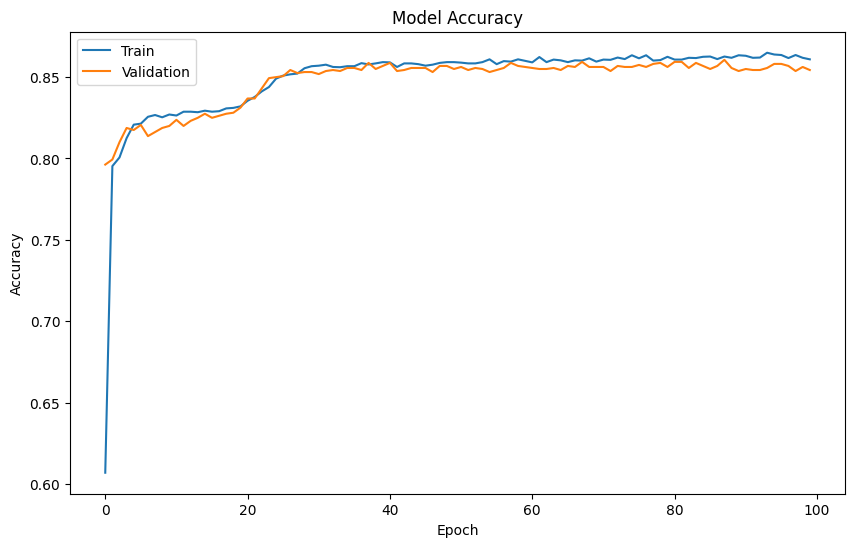

In [ ]:
# Accuracy Graph
plt.figure (figsize=(10,6))
plt.plot (history.history['accuracy'], label ="training acc")
plt.plot (history.history['val_accuracy'])
plt.title ('Model Accuracy')
plt.ylabel ('Accuracy')
plt.xlabel ('Epoch')
plt.legend (['Train', 'Validation'], loc='upper left')

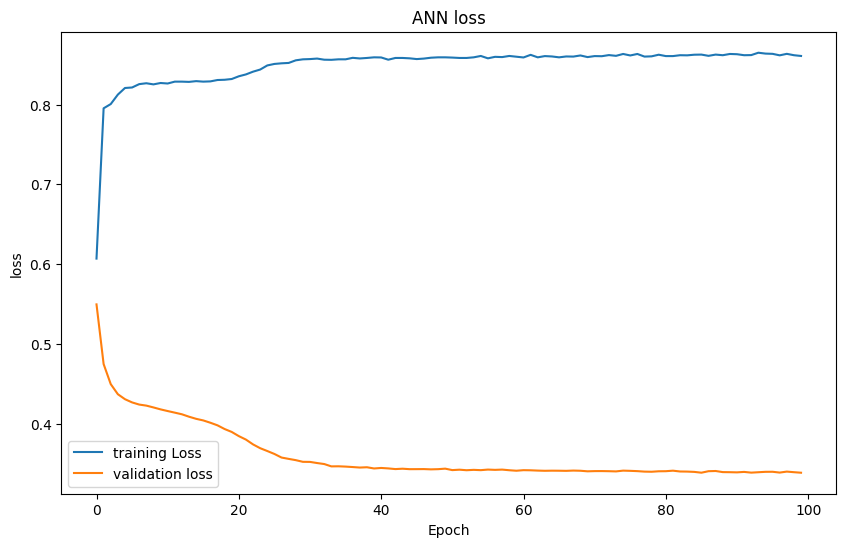

In [ ]:
# loss grapgh
plt.figure (figsize=(10,6))
plt.plot (history.history['accuracy'], label ="training Loss")
plt.plot (history.history['val_loss'], label = 'validation loss')
plt.title ('ANN loss')
plt.ylabel ('loss')
plt.xlabel ('Epoch')
plt.legend ()
plt.show()